In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATASET = "cahousing"

QI_COLUMNS = [
    "longitude",
    "latitude",
    "housing_median_age",
    "median_income",
    "median_house_value"
]

SENSITIVE_COLUMN = "ocean_proximity"

RESULT_DIR = "results/cahousing/topdown"

In [3]:
def validate_privacy(df, qi_columns, sensitive_column, k, l=None):
    equivalence_classes = df.groupby(qi_columns, dropna=False)
    class_sizes = equivalence_classes.size()

    result = {
        "equivalence_classes": len(class_sizes),
        "min_class_size": class_sizes.min(),
        "k_violations": int((class_sizes < k).sum())
    }

    if l is not None:
        diversity = equivalence_classes[sensitive_column].nunique()

        result.update({
            "min_l_diversity": diversity.min(),
            "l_violations": int((diversity < l).sum())
        })
    else:
        result.update({
            "min_l_diversity": None,
            "l_violations": None
        })
    return result

In [4]:
def load_result(k, l=None):
    if l is None:
        filename = f"cahousing_anonymized_k{k}.csv"
    else:
        filename = f"cahousing_anonymized_k{k}_l{l}.csv"

    path = os.path.join(RESULT_DIR, filename)

    return pd.read_csv(path, sep=";")

In [5]:
df_k2 = load_result(k=2)

validate_privacy(
    df_k2,
    QI_COLUMNS,
    SENSITIVE_COLUMN,
    k=2
)

{'equivalence_classes': 8544,
 'min_class_size': np.int64(2),
 'k_violations': 0,
 'min_l_diversity': None,
 'l_violations': None}

In [6]:
df_k2_l2 = load_result(k=2, l=2)

validate_privacy(
    df_k2_l2,
    QI_COLUMNS,
    SENSITIVE_COLUMN,
    k=2,
    l=2
)

{'equivalence_classes': 669,
 'min_class_size': np.int64(2),
 'k_violations': 0,
 'min_l_diversity': np.int64(2),
 'l_violations': 0}

In [7]:
results = [
    {
        "k": 2,
        "l": None,
        "method": "TDG k-anonymity",
        "NCP": 0.155,
        "CAVG": 1.208,
        "DM": 56764
    },
    {
        "k": 2,
        "l": 2,
        "method": "TDG + l-diversity",
        "NCP": 0.469,
        "CAVG": 15.426,
        "DM": 4360456
    }
]

results_df = pd.DataFrame(results)
results_df

,k,l,method,NCP,CAVG,DM
0,2,NaN,TDG k-anonymity,0.155,1.208,56764
1,2,2.0,TDG + l-diversity,0.469,15.426,4360456


In [8]:
evaluated_results = []

for row in results:
    k = row["k"]
    l = row["l"]

    df = load_result(k=k, l=l)

    privacy = validate_privacy(
        df,
        QI_COLUMNS,
        SENSITIVE_COLUMN,
        k=k,
        l=l
    )

    evaluated_results.append({
        **row,
        **privacy
    })

evaluation_df = pd.DataFrame(evaluated_results)
evaluation_df

,k,l,method,NCP,CAVG,DM,equivalence_classes,min_class_size,k_violations,min_l_diversity,l_violations
0,2,NaN,TDG k-anonymity,0.155,1.208,56764,8544,2,0,NaN,NaN
1,2,2.0,TDG + l-diversity,0.469,15.426,4360456,669,2,0,2.0,0.0


<Axes: xlabel='method'>

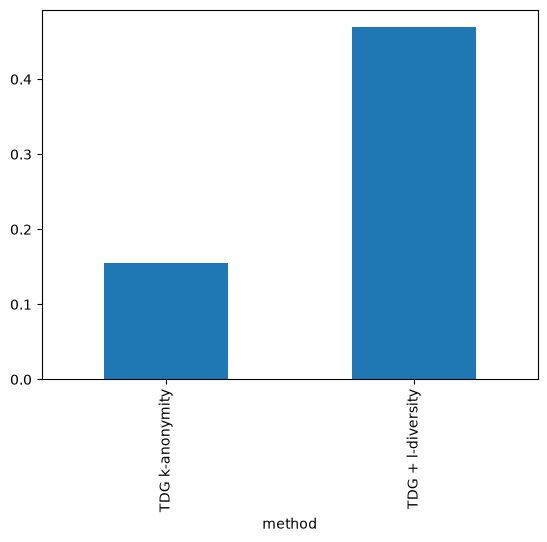

In [13]:
evaluation_df.plot(
    x="method",
    y="NCP",
    kind="bar",
    legend=False
)